# Example: Turnover Cost, Attribution, and Rebalance Diagnostics

Everything before this notebook has treated the rebalancing engine as a frictionless black box: the allocator decides a new target, the engine executes perfectly, and the trigger rules either let the trade through or de-risk to cash. Real-world engines live inside three constraints the earlier notebooks ignored:

* __Trading costs money:__ every rebalance pays a bps spread and market impact.
* __Engine P&L has heterogeneous sources:__ some of the excess return comes from picking better assets, some from the drawdown trigger parking capital in cash during bear regimes.
* __Triggers fire in identifiable patterns:__ a handful of days out of 252 contain most of the engine's decisions, and knowing when those days occurred is the key to debugging engine behavior.

This notebook explores these gaps: a per-trade cost sweep, a 3-way attribution ablation, and a rebalance-event timeline colored by drawdown state.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Measure transaction-cost sensitivity:__ Sweep a per-trade cost across a representative range and measure the strategy's terminal wealth as a function of friction. Identify the break-even cost at which the active strategy's advantage over a passive baseline disappears, which is the strategy's cost budget.
> * __Decompose excess wealth into operational contributions:__ Decompose an active strategy's excess wealth into the contributions from utility choice, dynamic reallocation, and risk-management triggers via a paired ablation across a Monte Carlo scenario. Attribute edge to its operational source so design decisions point at the right component.
> * __Visualize rebalance-event dynamics on a timeline:__ Classify each trading day in the realized run as rebalance, de-risk, or hold, and place these events on a timeline alongside trade size. Read when the strategy was active and which trades were most aggressive to reconstruct the engine's behavior post hoc.

Let's dive in!

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Implementations
Notebook-local helpers used by the cost-sweep analysis and the bias-correction step in Task 2.

`interp_breakeven(xs, ys, threshold)` does a linear-interpolation scan over a monotone-ish `(xs, ys)` curve and returns the `x` where `y` crosses `threshold`. Used to answer _at what transaction cost does the engine break even with the S1 min-var buy-and-hold?_ and _at what cost does it break even with risk-free net present value (NPV) = 0?_. Returns `Inf` if the whole curve sits above the threshold, `-Inf` if entirely below.

`apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr, Δt)` mirrors the helper of the same name in the Core Monte-Carlo evaluation notebook. It applies a uniform per-step exponential drag to every wealth path so each path's continuously-compounded growth rate falls by `bias_pct_per_yr` per year. Per-path rank order is preserved; the entire distribution is location-shifted in CCGR space. We use it in Task 2 to anchor the daily-rebalanced engine arms (full and no-trigger) to `ENGINE_PRIOR_CCGR_PCT` so the dynamic-reallocation contribution reflects real allocation alpha rather than the SIM rebalancing-alpha artifact (Booth & Fama 1992 diversification return on iid SIM residuals).

In [2]:
"""
    interp_breakeven(xs::Vector{Float64}, ys::Vector{Float64}, threshold::Float64) -> Float64

Linear-interpolation scan over `(xs, ys)` returning the `x` at which `y`
crosses `threshold`. Assumes `xs` is sorted ascending. Returns `Inf` if
the curve never dips to `threshold`, `-Inf` if it never reaches it from
below.
"""
function interp_breakeven(xs::Vector{Float64}, ys::Vector{Float64}, threshold::Float64)::Float64
    for i ∈ 1:(length(xs) - 1)
        if (ys[i] - threshold) * (ys[i+1] - threshold) <= 0.0
            frac = (ys[i] - threshold) / (ys[i] - ys[i+1]);
            return xs[i] + frac * (xs[i+1] - xs[i]);
        end
    end
    return ys[end] > threshold ? Inf : -Inf;
end;

"""
    apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr, Δt) -> MyBacktestResult

Apply a uniform per-step exponential drag to every wealth path so each
path's continuously-compounded growth rate is reduced by `bias_pct_per_yr` /
year. Mirror of the helper of the same name in the Core Monte-Carlo
evaluation notebook. Per-path rank order is preserved; the entire
distribution is location-shifted in CCGR space. Used in Task 2 to anchor
the synthetic engine's median CCGR to `ENGINE_PRIOR_CCGR_PCT` so the
dynamic-reallocation contribution does not double-count the SIM
rebalancing-alpha artifact.
"""
function apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr::Float64,
        Δt::Float64)::MyBacktestResult
    n_t, n_p = size(r.wealth_paths);
    drag = exp.(-bias_pct_per_yr / 100.0 .* (0:(n_t-1)) .* Δt);
    Wc = r.wealth_paths .* drag;

    final_wealth_c  = Wc[end, :];
    max_drawdowns_c = zeros(n_p);
    sharpe_ratios_c = zeros(n_p);
    for p ∈ 1:n_p
        wealth = Wc[:, p];
        peak = accumulate(max, wealth);
        max_drawdowns_c[p] = maximum((peak .- wealth) ./ peak);
        vol = std(diff(wealth) ./ wealth[1:end-1]) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        sharpe_ratios_c[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end

    rc = MyBacktestResult();
    rc.scenario_label = r.scenario_label;
    rc.strategy_label = r.strategy_label * " [bias-corrected $(round(bias_pct_per_yr, digits=2))pp/yr]";
    rc.final_wealth   = final_wealth_c;
    rc.max_drawdowns  = max_drawdowns_c;
    rc.sharpe_ratios  = sharpe_ratios_c;
    rc.wealth_paths   = Wc;
    return rc;
end;

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, its purpose, units, etc.

In [3]:
# Turnover-diagnostics configuration
B₀ = 10_000.0                 # starting budget (USD)
Δt = 1.0 / 252.0              # trading-day step (years)
L_short = 21                  # short EMA window (days)
L_long = 63                   # long EMA window (days)
L_growth = 10                 # EMA window for smoothed market growth rate (days)
GAIN = 10.0                   # gain constant G for λ signal (dimensionless)
offset = L_short + L_long     # warmup offset before trading begins (days)
T_total = offset + 252        # total path length (days)
TRIGGER_MAX_DRAWDOWN = 0.15   # drawdown trigger threshold (circuit breaker)
TRIGGER_MAX_TURNOVER = 0.50   # max fraction of wealth traded per rebalance
ALLOCATION_EPSILON = 0.1      # minimum share count for non-preferred assets
SCENARIO_SEED = 2026          # RNG seed (matches Example 1 + Example 4)
ENGINE_PRIOR_CCGR_PCT = 32.0  # bias-correction anchor (matches Core MC notebook); tunable
COST_GRID = [0.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0]  # cost sweep grid (basis points per trade)

7-element Vector{Float64}:
   0.0
   5.0
  10.0
  25.0
  50.0
 100.0
 200.0

To get started, we load the same S1 universe that every other Session 2 notebook uses and build the single-path scenario + engine context. In the code block below, we populate:

* `my_tickers::Vector{String}`: ticker universe from Session 1.
* `sim_estimates::Vector{MySIMParameterEstimate}`: per-ticker SIM fits.
* `allocation_weights::Vector{Float64}`: Session 1 min-var weights.
* `g_f::Float64`: continuously compounded risk-free rate.
* `N::Int`: number of tickers.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: SIM adapter dict for preference-weight computation.
* `market_prices::Vector{Float64}`: synthetic market (index) path.
* `price_matrix::Matrix{Float64}`: per-ticker price paths.
* `lambda_series::Vector{Float64}`: EMA-crossover sentiment signal.
* `gm_ema::Vector{Float64}`: smoothed market growth rate.
* `context::MyRebalancingContextModel`: engine context bundled for the rebalancing run.
* `rules::MyTriggerRules`: trigger rules (drawdown limit, turnover cap, reallocation schedule).

The cell also returns four artifacts reused by the Task 2 ablation:

* `market_model_g::JumpHiddenMarkovModel`: market generative model used to regenerate the multi-path scenario inline.
* `portfolio_g::MyPortfolioSurrogateModel`: per-ticker marginals plus copula for the inline regeneration.
* `calib_g::Dict{String,Any}`: SIM calibration dict for the inline regeneration.
* `start_prices_g::Dict{String,Float64}`: per-ticker starting prices for the inline regeneration.

In [4]:
my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_prices, price_matrix, lambda_series, gm_ema, context, rules, market_model_g, portfolio_g, calib_g, start_prices_g = let
    # --- Step 1: S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers         = minvar["my_tickers"]::Vector{String};
    sim_estimates      = minvar["sim_estimates"];
    allocation_weights = Float64.(minvar["allocation_weights"]);
    g_f                = Float64(minvar["g_f"]);
    N  = length(my_tickers);

    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 2: Regenerate the Example 1 single forward path ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap         = MyCurrentPrices();
    snap_lookup  = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    T_total = 336;
    n_trading_days        = T_total - offset;
    Δt = 1.0 / 252.0;

    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Diagnostics (1p)", seed = 2026);

    market_prices = scenario.market_paths[1, :];
    price_matrix  = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    for k ∈ 1:N
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 3: EMA λ, gm_ema, context, rules ---
    ema_short = compute_ema(market_prices; window = 21);
    ema_long  = compute_ema(market_prices; window = 63);
    lambda_series = compute_lambda(ema_short, ema_long; G = GAIN);
    lambda_series[1:offset] .= 0.0;
    gm_raw = compute_market_growth(market_prices; Δt = Δt);
    gm_ema = compute_ema(gm_raw; window = L_growth);

    context = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_ema, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
    ));
    rules = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 4: Keep scenario around for the 5,000-path attribution task ---
    market_model_g = market_model;
    portfolio_g    = portfolio;
    calib_g        = calib;
    start_prices_g = start_prices;

    println("Single-path scenario ready: $(T_total) days, $(N) tickers, offset=$(offset)")
    my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_prices, price_matrix, lambda_series, gm_ema, context, rules, market_model_g, portfolio_g, calib_g, start_prices_g
end


Single-path scenario ready: 336 days, 20 tickers, offset=84


(["NFLX", "AMZN", "NKE", "TSLA", "COST", "SLB", "JPM", "V", "MA", "LLY", "ABBV", "CAT", "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "ADBE", "FCX", "AMT"], MySIMParameterEstimate[MySIMParameterEstimate("NFLX", 0.1322865632928942, 1.2010307678308083, 6.379448149349787, 0.25697243174005713), MySIMParameterEstimate("AMZN", 0.08774813260985524, 1.231420093170866, 3.69418455547533, 0.5202027326204726), MySIMParameterEstimate("NKE", -0.06426864857748543, 1.1708203153348677, 3.8495781250354706, 0.4744025627155928), MySIMParameterEstimate("TSLA", 0.15474883758966768, 1.728289381540776, 7.160880271295703, 0.36239988402121115), MySIMParameterEstimate("COST", 0.11032131109851778, 0.7267015904419676, 2.626819443273204, 0.4275173082384095), MySIMParameterEstimate("SLB", -0.2149363514169727, 1.305437201526172, 5.235883969365685, 0.37755081327817375), MySIMParameterEstimate("JPM", 0.0006227864734404588, 1.2027677287695575, 2.630357361891024, 0.671074699975431), MySIMParameterEstimate("V", 0.039851079033263

___
## Task 1: Transaction Cost Sensitivity
In this task, we introduce transaction costs into the Cobb-Douglas engine and measure their impact on terminal wealth. Up to this point every engine run has been frictionless. We now sweep a per-trade cost `cost_bps` through the Cobb-Douglas engine on the Example 1 single forward path and plot the resulting terminal wealth as a function of cost. The cost is applied inside [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.run_rebalancing_engine) on each trade: for every rebalance it debits `cost_bps / 10,000 × realized_trade_value` from the new cash balance, so the compounding math stays exact. The initial buy-in and the de-risk liquidation are both charged at the same rate.

> __What should we see?__
>
> Terminal wealth should fall approximately linearly with cost in basis points (each bp costs approximately `realized turnover / year` basis points of final wealth). At zero cost the engine delivers its full headline return (+49% on this path with the original run); as cost rises the engine's edge shrinks and eventually crosses two reference lines: (1) the S1 min-var terminal wealth (the _beats static_ break-even), and (2) the risk-free terminal wealth $B_0 \cdot e^{g_f T}$ (the NPV-break-even, the cost at which the engine stops beating a T-bill). The NPV break-even is the **harder test**: it answers _at what cost is adaptive rebalancing no longer worth taking any risk at all?_ The engine's cost budget is tighter in NPV terms than in min-var terms whenever min-var itself underperforms the risk-free baseline.

In the code block below, we sweep `cost_bps ∈ {0, 5, 10, 25, 50, 100, 200}`, run the engine at each value, compute both terminal `W/W₀` and `NPV/W₀`, and plot a two-panel figure: terminal wealth vs cost on the left, NPV vs cost on the right. Both break-even costs are computed by linear interpolation and printed. The sweep terminals escape as `cost_terminals::Dict{Float64,Float64}` and `cost_npvs::Dict{Float64,Float64}`.

Terminal W/W₀ and NPV/W₀ by cost_bps:
  cost_bps |  W/W₀   |  NPV/W₀
  ---------+---------+---------
  0.0      |  1.562  |  0.493
  5.0      |  1.506  |  0.44
  10.0     |  1.452  |  0.388
  25.0     |  1.231  |  0.177
  50.0     |  1.115  |  0.066
  100.0    |  0.919  |  -0.121
  200.0    |  0.855  |  -0.183

Cost-free references:
  S1 Min-Var:  W/W₀ = 1.126,  NPV/W₀ = 0.077
  Risk-Free:   W/W₀ = 1.046,  NPV/W₀ = 0.000

Break-even costs (linearly interpolated from the grid):
  Engine W vs Min-Var W:       47.6 bps  (engine stops beating S1 static)
  Engine W vs Risk-Free W:     67.6 bps  (engine stops beating a T-bill)
  Engine NPV ≤ 0:              67.6 bps  (sanity check; identical to row above)


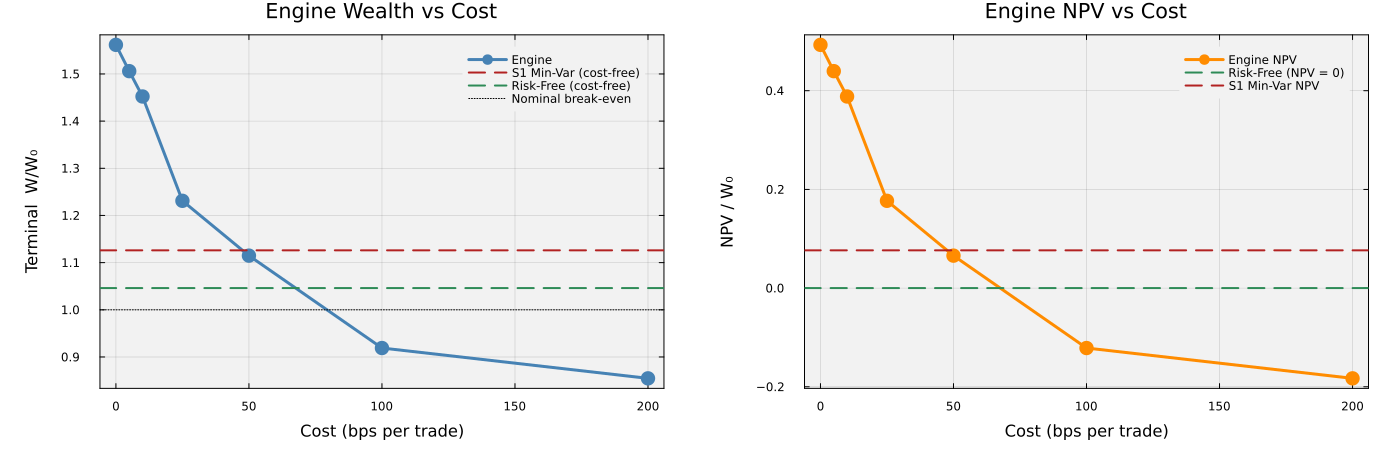

(Dict(0.0 => 1.5616493101517768, 5.0 => 1.5059221079824219, 50.0 => 1.114824330479148, 200.0 => 0.8546948161321533, 25.0 => 1.231043428256305, 10.0 => 1.4521894496279142, 100.0 => 0.9189882892532414), Dict(0.0 => 0.4929328080114963, 5.0 => 0.43965774306798905, 50.0 => 0.06576925262433705, 200.0 => -0.18291390804185712, 25.0 => 0.17687441744021398, 10.0 => 0.3882894569888813, 100.0 => -0.12144950963979281))

In [5]:
cost_terminals, cost_npvs = let
    # --- Step 1: Cost grid + baseline references ---
    cost_terminals = Dict{Float64, Float64}();
    cost_npvs      = Dict{Float64, Float64}();

    # Active window length and discount factor (for NPV)
    T_active = (size(price_matrix, 1) - offset) / 252;
    discount = exp(-g_f * T_active);

    # S1 min-var buy-and-hold terminal (cost-free) on this single path
    p_start    = [price_matrix[offset + 1, k + 1] for k ∈ 1:N];
    shares_mv  = B₀ .* allocation_weights ./ p_start;
    mv_terminal = sum(shares_mv[k] * price_matrix[end, k + 1] for k ∈ 1:N);
    mv_W_ratio  = mv_terminal / B₀;
    mv_NPV_ratio = (mv_terminal * discount - B₀) / B₀;

    # Risk-free terminal: B₀ · exp(g_f · T_active). NPV ≡ 0 by construction.
    rf_W_ratio = exp(g_f * T_active);

    # --- Step 2: Sweep cost_bps, collect terminal W/W₀ and NPV/B₀ ---
    for c ∈ COST_GRID
        ctx_c = deepcopy(context);
        results_c = run_rebalancing_engine(ctx_c, rules, lambda_series;
            offset = offset, allocator = :cobb_douglas, cost_bps = c);
        wealth = compute_wealth_series(results_c, price_matrix, my_tickers; offset = offset);
        cost_terminals[c] = wealth[end] / B₀;
        cost_npvs[c]      = (wealth[end] * discount - B₀) / B₀;
    end

    # --- Step 3: Linear-interpolation break-even costs ---
    sorted_keys = sort(collect(keys(cost_terminals)));
    ys_W        = [cost_terminals[c] for c ∈ sorted_keys];
    ys_NPV      = [cost_npvs[c]      for c ∈ sorted_keys];

    be_mv_wealth = interp_breakeven(Float64.(sorted_keys), ys_W,   mv_W_ratio);
    be_rf_wealth = interp_breakeven(Float64.(sorted_keys), ys_W,   rf_W_ratio);
    be_rf_npv    = interp_breakeven(Float64.(sorted_keys), ys_NPV, 0.0);

    # --- Step 4: Two-panel plot ---
    xs = Float64.(sorted_keys);
    p1 = plot(xs, ys_W,
        lw = 3, c = :steelblue, ms = 8, msc = :steelblue, marker = :circle,
        xlabel = "Cost (bps per trade)", ylabel = "Terminal  W/W₀",
        title = "Engine Wealth vs Cost",
        fontsize = 16, label = "Engine");
    hline!(p1, [mv_W_ratio],  lw = 2, ls = :dash, c = :firebrick, label = "S1 Min-Var (cost-free)");
    hline!(p1, [rf_W_ratio],  lw = 2, ls = :dash, c = :seagreen,  label = "Risk-Free (cost-free)");
    hline!(p1, [1.0],         lw = 1, ls = :dot,  c = :black,     label = "Nominal break-even");
    plot!(p1, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    p2 = plot(xs, ys_NPV,
        lw = 3, c = :darkorange, ms = 8, msc = :darkorange, marker = :circle,
        xlabel = "Cost (bps per trade)", ylabel = "NPV / W₀",
        title = "Engine NPV vs Cost",
        fontsize = 16, label = "Engine NPV");
    hline!(p2, [0.0],          lw = 2, ls = :dash, c = :seagreen,  label = "Risk-Free (NPV = 0)");
    hline!(p2, [mv_NPV_ratio], lw = 2, ls = :dash, c = :firebrick, label = "S1 Min-Var NPV");
    plot!(p2, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    # --- Step 5: Report ---
    println("Terminal W/W₀ and NPV/W₀ by cost_bps:")
    println("  cost_bps |  W/W₀   |  NPV/W₀")
    println("  ---------+---------+---------")
    for c ∈ sorted_keys
        println("  ", rpad(c, 8), " |  ",
                rpad(round(cost_terminals[c], digits=3), 6), " |  ",
                round(cost_npvs[c], digits=3))
    end
    println()
    println("Cost-free references:")
    println("  S1 Min-Var:  W/W₀ = $(round(mv_W_ratio, digits=3)),  NPV/W₀ = $(round(mv_NPV_ratio, digits=3))")
    println("  Risk-Free:   W/W₀ = $(round(rf_W_ratio, digits=3)),  NPV/W₀ = 0.000")
    println()
    println("Break-even costs (linearly interpolated from the grid):")
    println("  Engine W vs Min-Var W:       $(round(be_mv_wealth, digits=1)) bps  (engine stops beating S1 static)")
    println("  Engine W vs Risk-Free W:     $(round(be_rf_wealth, digits=1)) bps  (engine stops beating a T-bill)")
    println("  Engine NPV ≤ 0:              $(round(be_rf_npv,    digits=1)) bps  (sanity check; identical to row above)")

    display(plot(p1, p2, layout = (1, 2), size = (1400, 450), 
        left_margin = 12Plots.mm, right_margin = 6Plots.mm,
        top_margin = 4Plots.mm, bottom_margin = 8Plots.mm));
    (cost_terminals, cost_npvs)
end


___
## Task 2: Three-Way Attribution, Utility vs Reallocation vs Trigger
In this task, we decompose the engine's excess wealth into three attributed components: utility choice, dynamic reallocation, and trigger effect.

The engine's excess wealth over the S1 min-var baseline has three independently identifiable sources, and they can be teased apart by running four strategies on the same multi-path scenario and differencing them:

1. **Utility choice:** does Cobb-Douglas, held fixed, beat covariance-based min-var? We answer this with the `Static CD (warmup-avg λ)` baseline from the stress-test notebook: fit $\gamma$ once from the warmup-averaged EMA-crossover $\lambda$, allocate once, and hold. The gap `Static CD − S1 Min-Var` is the *utility-choice contribution*.
2. **Dynamic reallocation:** does updating $\gamma$ daily help? We answer this with the `no-trigger engine` ablation: the full Cobb-Douglas engine but with `max_drawdown = 10.0` (effectively no drawdown circuit breaker). The gap `No-trigger engine − Static CD` is the *dynamic-reallocation contribution*.
3. **Risk management:** does the drawdown trigger help? The gap `Full engine − No-trigger engine` is the *trigger contribution*.

Formally, per path: $\Delta W_{\text{total}} = W_{\text{full}} - W_{\text{mv}}$ decomposes as $\Delta W_{\text{util}} + \Delta W_{\text{dynamic}} + \Delta W_{\text{trigger}}$ by construction. Over the path ensemble we compute medians on the full distribution and means on two different tail slices.

**Bias correction.** The full engine and the no-trigger engine are both daily-rebalanced, so both inherit the SIM rebalancing-alpha artifact (Booth & Fama 1992 diversification return on iid SIM residuals) that the Core MC notebook documents. Static CD and Min-Var are buy-and-hold, so they do not. We follow the Core MC convention: compute `bias_pct_per_yr` from the full engine's raw median CCGR vs `ENGINE_PRIOR_CCGR_PCT`, apply the same correction to both daily-rebalanced arms, and leave the two passive arms at their raw synthetic levels. Telescoping (`util + dyn + trig = total`) is preserved by construction.

> __What should we see?__
>
> Before correction, the **dynamic-reallocation contribution dominates by a wide margin** because most of the +28pp/yr daily-rebalancing alpha that iid SIM residuals generate flows into this component. After correction, the dynamic-reallocation contribution shrinks substantially and converges toward what real-market autocorrelation (~0.05 to 0.10 daily) actually delivers; the **utility-choice contribution is unchanged** because it is computed on two passive arms; the **trigger contribution is unchanged** because the same uniform shift is applied to both engine arms in the trigger gap. The headline question _where is the engine's edge coming from?_ is answered honestly only on the corrected attribution.

In the code block below, we regenerate the same multi-path scenario used by the stress-test notebook, run both engine arms inline via [the `backtest_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_engine) (so each arm produces `wealth_paths` for `apply_bias_correction`), compute `bias_pct_per_yr`, apply correction to the full and no-trigger engine arms, load the Static CD and Min-Var arrays from `stress-test-engine.jld2` (passive, raw), and return four per-path excess arrays:

* `util_contribution::Vector{Float64}`: utility-choice contribution, computed per path as Static CD minus Min-Var (passive minus passive; raw).
* `dynamic_contribution::Vector{Float64}`: dynamic-reallocation contribution, per path as no-trigger engine (corrected) minus Static CD (raw).
* `trigger_contribution::Vector{Float64}`: trigger contribution, per path as full engine (corrected) minus no-trigger engine (corrected).
* `total_excess::Vector{Float64}`: total engine excess, per path as full engine (corrected) minus Min-Var (raw).

By construction `util + dynamic + trigger == total` for every path.

In [6]:
util_contribution, dynamic_contribution, trigger_contribution, total_excess = let
    n_paths = 5_000;
    n_steps = 336;
    seed    = 2026;
    Δt_loc      = 1.0 / 252.0;
    offset_loc  = 84;

    # --- Step 1: Regenerate the identical 5,000-path scenario ---
    println("Regenerating $(n_paths)-path scenario (seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model_g, portfolio_g, calib_g, my_tickers;
        n_paths = n_paths, n_steps = n_steps, Δt = Δt_loc,
        start_prices = start_prices_g,
        label = "S2 Attribution ($(n_paths)p)", seed = seed);

    # --- Step 2: Run the full engine arm (DD = 15%, τ = 50%) inline ---
    # Calling the library backtest_engine directly so we get the (n_t, n_p)
    # wealth_paths matrix that apply_bias_correction needs.
    println("Running full engine across $(n_paths) paths...")
    rules_full = (max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);
    r_full_raw = backtest_engine(scen, my_tickers, sim_params, rules_full;
        B₀ = B₀, offset = offset_loc,
        N_short = L_short, N_long = L_long,
        GAIN = GAIN, N_growth = L_growth);
    r_full_raw.strategy_label = "Cobb-Douglas Engine raw (DD≤$(Int(TRIGGER_MAX_DRAWDOWN*100))%, τ≤$(Int(TRIGGER_MAX_TURNOVER*100))%)";

    # --- Step 3: Run the no-trigger engine ablation inline ---
    # max_drawdown = 10.0 makes the trigger unreachable; everything else
    # matches the full arm so the only difference is the circuit breaker.
    println("Running no-trigger engine across $(n_paths) paths...")
    rules_notrig = (max_drawdown = 10.0, max_turnover = TRIGGER_MAX_TURNOVER);
    r_notrig_raw = backtest_engine(scen, my_tickers, sim_params, rules_notrig;
        B₀ = B₀, offset = offset_loc,
        N_short = L_short, N_long = L_long,
        GAIN = GAIN, N_growth = L_growth);
    r_notrig_raw.strategy_label = "Cobb-Douglas Engine raw (no-trigger ablation)";
    no_trigger_dd = r_notrig_raw.max_drawdowns;

    # --- Step 4: Bias correction on the daily-rebalanced arms only ---
    # bias_pct_per_yr is derived from the full engine's raw median CCGR
    # (mirrors the Core MC notebook's anchor logic) and applied to BOTH
    # engine arms so the trigger gap (full − no-trigger) is invariant.
    full_med_ccgr_raw = let
        gs = Float64[];
        for p ∈ 1:n_paths
            w = r_full_raw.wealth_paths[:, p];
            push!(gs, log(w[end] / w[1]) / ((length(w) - 1) * Δt_loc) * 100);
        end
        median(gs)
    end
    bias_pct_per_yr = full_med_ccgr_raw - ENGINE_PRIOR_CCGR_PCT;
    println("  Full-engine raw median CCGR: $(round(full_med_ccgr_raw, digits=2))%/yr")
    println("  Real-2025 anchor:            $(ENGINE_PRIOR_CCGR_PCT)%/yr")
    println("  Bias correction drag:        $(round(bias_pct_per_yr, digits=2))pp/yr (applied to engine arms only)")

    r_full   = apply_bias_correction(r_full_raw,   bias_pct_per_yr, Δt_loc);
    r_notrig = apply_bias_correction(r_notrig_raw, bias_pct_per_yr, Δt_loc);
    full_W            = r_full.final_wealth;
    no_trigger_wealth = r_notrig.final_wealth;

    # --- Step 5: Load the passive baseline arrays (Static CD, Min-Var) raw ---
    # These two arms are buy-and-hold after the buy-in so they do not carry
    # the SIM rebalancing-alpha artifact and stay at their raw synthetic level.
    baseline = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    scd_W    = Float64.(baseline["scd_w_final_wealth"]);
    mv_W     = Float64.(baseline["mv_final_wealth"]);

    # --- Step 6: 3-way decomposition (per-path arrays) ---
    util_c   = scd_W               .- mv_W;            # Utility choice (passive − passive; raw)
    dyn_c    = no_trigger_wealth   .- scd_W;           # Dynamic realloc (engine corrected − passive raw)
    trig_c   = full_W              .- no_trigger_wealth;  # Risk mgmt (corrected − corrected; shift cancels)
    total_e  = full_W              .- mv_W;            # Total excess (engine corrected − passive raw)

    # --- Step 7: Tail slices ---
    n_tail   = max(1, floor(Int, 0.05 * n_paths));
    worst_mv = partialsortperm(mv_W,           1:n_tail);
    worst_dd = partialsortperm(no_trigger_dd,  1:n_tail; rev = true);
    dd_lo_pct = round(100 * no_trigger_dd[worst_dd[end]], digits = 2);
    dd_hi_pct = round(100 * no_trigger_dd[worst_dd[1]],   digits = 2);

    # --- Step 8: Wide-form attribution DataFrame (rows = component) ---
    components = [
        ("Total excess (Full − Min-Var)",     total_e),
        ("Utility choice (Static CD − MV)",   util_c),
        ("Dynamic reallocation (NoTrig − SCD)", dyn_c),
        ("Trigger (Full − NoTrig)",           trig_c),
    ];
    attribution_df = DataFrame(
        "Component"                                          => [c[1] for c ∈ components],
        "Full sample median (\$)"                            => [round(median(c[2]),                  digits = 0) for c ∈ components],
        "Full sample (% of B₀)"                              => [round(median(c[2]) / B₀ * 100,       digits = 2) for c ∈ components],
        "Tail-a (worst MV) mean (\$)"                        => [round(mean(c[2][worst_mv]),          digits = 0) for c ∈ components],
        "Tail-a (% of B₀)"                                   => [round(mean(c[2][worst_mv]) / B₀ * 100, digits = 2) for c ∈ components],
        "Tail-b (worst NoTrig DD) mean (\$)"                 => [round(mean(c[2][worst_dd]),          digits = 0) for c ∈ components],
        "Tail-b (% of B₀)"                                   => [round(mean(c[2][worst_dd]) / B₀ * 100, digits = 2) for c ∈ components],
    );
    println("3-way attribution across $(n_paths) paths (engine arms bias-corrected to anchor=$(ENGINE_PRIOR_CCGR_PCT)%/yr):")
    println("  Tail-a slice: worst $(n_tail) paths by S1 min-var terminal wealth")
    println("  Tail-b slice: worst $(n_tail) paths by no-trigger engine drawdown (DD range $(dd_lo_pct)% to $(dd_hi_pct)%)")
    pretty_table(attribution_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 9: Sanity check (medians do not add exactly) ---
    check = median(util_c) + median(dyn_c) + median(trig_c);
    sanity_df = DataFrame(
        "Quantity"            => ["median(total_excess)", "median(util) + median(dyn) + median(trig)"],
        "% of B₀"             => [
            round(median(total_e) / B₀ * 100, digits = 2),
            round(check / B₀ * 100,           digits = 2),
        ],
    );
    println("Sanity (medians do not add exactly):")
    pretty_table(sanity_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    util_c, dyn_c, trig_c, total_e
end;

Regenerating 5000-path scenario (seed=2026)...
Running full engine across 5000 paths...
Running no-trigger engine across 5000 paths...
  Full-engine raw median CCGR: 54.85%/yr
  Real-2025 anchor:            32.0%/yr
  Bias correction drag:        22.85pp/yr (applied to engine arms only)
3-way attribution across 5000 paths (engine arms bias-corrected to anchor=32.0%/yr):
  Tail-a slice: worst 250 paths by S1 min-var terminal wealth
  Tail-b slice: worst 250 paths by no-trigger engine drawdown (DD range 13.88% to 30.03%)
 ------------------------------------- ------------------------ ----------------------- ---------------------------- ------------------ ----------------------------------- ------------------
                            Component   Full sample median ($)   Full sample (% of B₀)   Tail-a (worst MV) mean ($)   Tail-a (% of B₀)   Tail-b (worst NoTrig DD) mean ($)   Tail-b (% of B₀) 
                               String                  Float64                 Float64       

The code below plots the four contribution distributions side by side (utility choice, dynamic reallocation, trigger, and total) as histograms with the median marked on each.

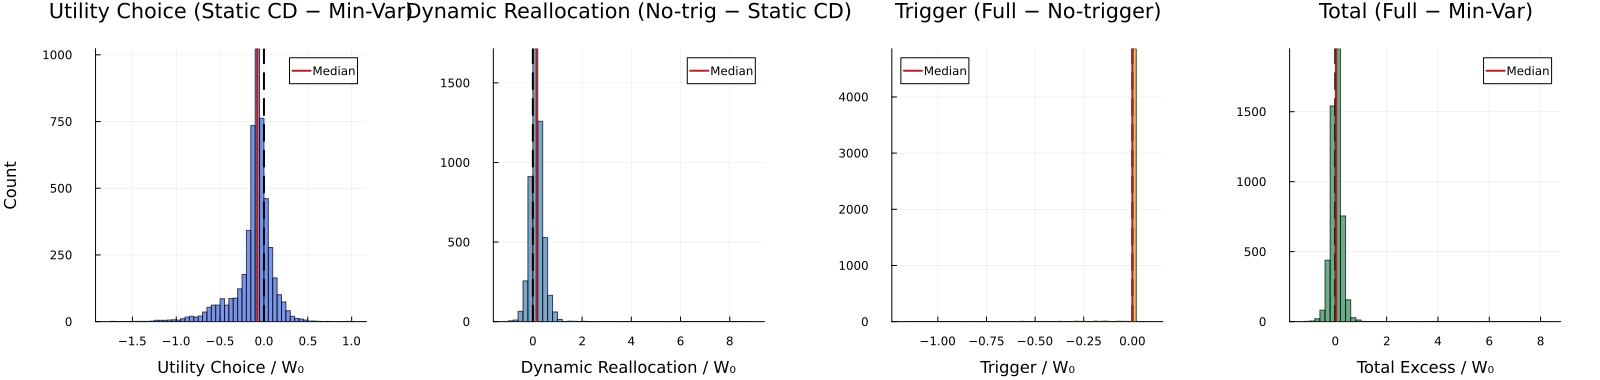

In [7]:
let
    bins = 60;

    # --- Panel 1: Utility-choice contribution (Static CD minus Min-Var) per path ---
    p1 = histogram(util_contribution ./ B₀, bins = bins, color = :royalblue, alpha = 0.7,
        xlabel = "Utility Choice / W₀", ylabel = "Count",
        title = "Utility Choice (Static CD − Min-Var)", label = "", fontsize = 14);
    vline!(p1, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p1, [median(util_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    # --- Panel 2: Dynamic-reallocation contribution (no-trigger engine minus Static CD) ---
    p2 = histogram(dynamic_contribution ./ B₀, bins = bins, color = :steelblue, alpha = 0.7,
        xlabel = "Dynamic Reallocation / W₀", ylabel = "",
        title = "Dynamic Reallocation (No-trig − Static CD)", label = "", fontsize = 14);
    vline!(p2, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p2, [median(dynamic_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    # --- Panel 3: Trigger contribution (full engine minus no-trigger engine) ---
    p3 = histogram(trigger_contribution ./ B₀, bins = bins, color = :goldenrod, alpha = 0.7,
        xlabel = "Trigger / W₀", ylabel = "",
        title = "Trigger (Full − No-trigger)", label = "", fontsize = 14);
    vline!(p3, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p3, [median(trigger_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    # --- Panel 4: Total engine excess (full engine minus Min-Var) ---
    p4 = histogram(total_excess ./ B₀, bins = bins, color = :seagreen, alpha = 0.7,
        xlabel = "Total Excess / W₀", ylabel = "",
        title = "Total (Full − Min-Var)", label = "", fontsize = 14);
    vline!(p4, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p4, [median(total_excess) / B₀], lw = 2, c = :firebrick, label = "Median");

    # --- Combine the four panels into a single 1×4 figure ---
    plot(p1, p2, p3, p4, layout = (1, 4), size = (1600, 380), margin = 8Plots.mm)
end

___
## Task 3: Rebalance Event Timeline
In this task, we reconstruct the engine's per-day decisions (rebalance, de-risk, hold) and plot a wealth and trade-size timeline.

Every entry in the engine's `results::Dict{Int, MyRebalancingResult}` carries the `shares`, `cash`, and `gamma` produced on that trading day. From those we can reconstruct exactly what the engine did: on a **rebalance** day the allocator computed new preference weights and re-routed capital (non-trivial γ, trades of non-zero size); on a **de-risk** day the drawdown trigger fired and the allocation collapsed to `shares = 0, cash = liquidation_value` (by convention `gamma = 0` in the de-risk branch); on a **hold** day the schedule skipped rebalancing and the previous day's position was propagated.

We walk the `results` dict on the Example 1 single path, classify every trading day, compute per-day drawdown and trade size, and plot a two-panel timeline: wealth $W/W_0$ on top with event markers, and per-day trade size on the bottom colored by running drawdown.

> __What should we see?__
>
> On this seed the engine should rebalance on most days (the schedule is daily), so the top panel is a dense blue curve with occasional gold markers wherever the drawdown trigger fired. Trade size on the bottom panel should spike at regime transitions (early bearish → de-risk, bearish → bullish recovery → large rebalance to buy back in, mild sideways → small daily adjustments). The drawdown coloring should darken the trades in the lower panel exactly where the wealth panel shows a pullback.

In the code block below, we run the engine, walk `results`, and build the diagnostic plot. The cell returns the diagnostic objects directly.

Engine events on this path:
  Total trading days:     252
  Rebalance days:         252
  De-risk days (trigger): 0
  Median trade size:      $5230.0
  P95 trade size:         $7731.0
  Max running drawdown:   11.71%
  P95 running drawdown:   10.34%


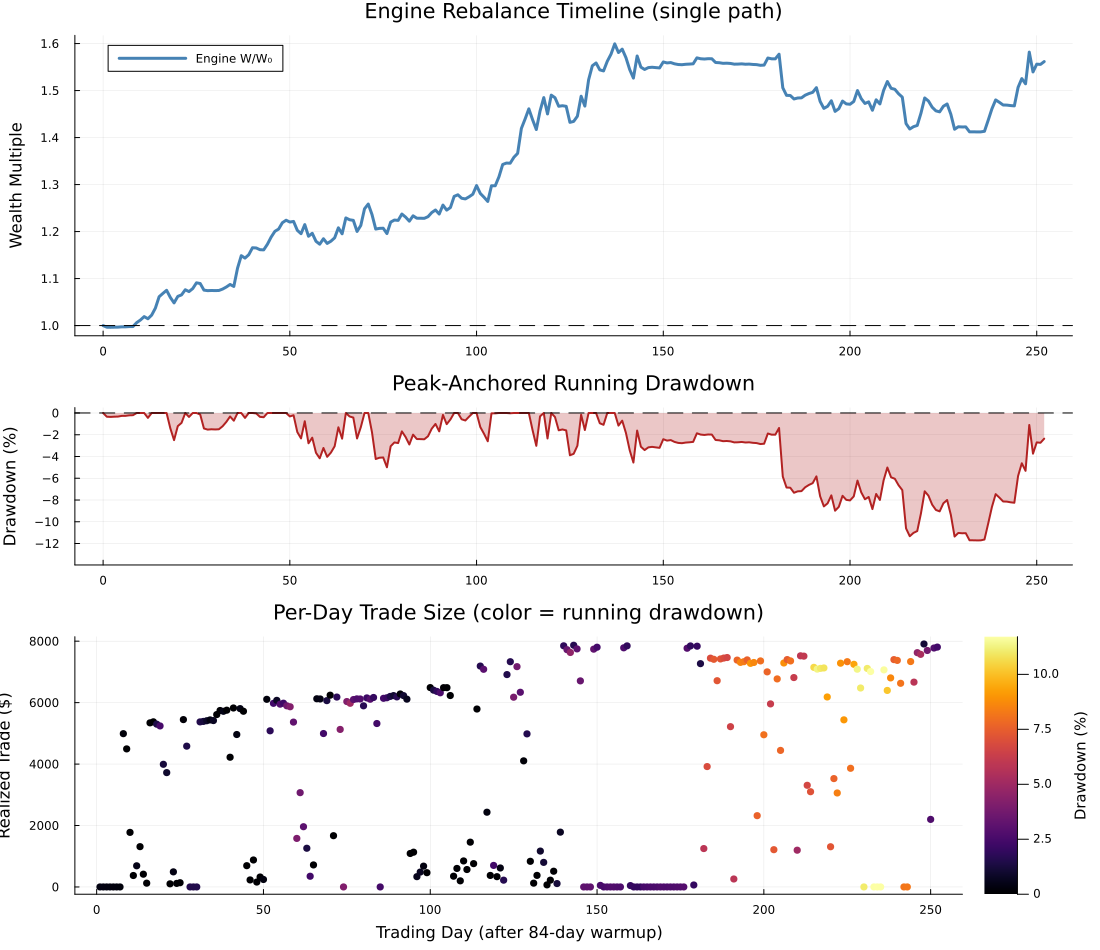

In [8]:
let
    # --- Step 1: Run the engine (cost_bps = 0, standard config) ---
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset = offset, allocator = :cobb_douglas);
    wealth = compute_wealth_series(results, price_matrix, my_tickers; offset = offset);

    n_active = length(wealth) - 1;
    # Per-day running peak and drawdown (percent): peak[t] = max of W up to t; drawdown = (peak − W)/peak.
    peak = accumulate(max, wealth);
    drawdown_pct = (peak .- wealth) ./ peak .* 100;

    # --- Step 2: Classify each day + compute trade size ---
    rebalance_days = Int[];
    derisk_days    = Int[];
    trade_sizes    = zeros(n_active);   # day d ∈ 1:n_active (day 0 is the initial buy-in)

    prev_shares = results[0].shares;
    prev_cash   = results[0].cash;

    for d ∈ 1:n_active
        r = results[d];
        actual_day = offset + d;

        # realized dollar trade vs previous day
        trade_val = sum(abs(r.shares[i] - prev_shares[i]) * price_matrix[actual_day, i + 1] for i ∈ 1:N);
        trade_sizes[d] = trade_val;

        # classify: de-risk branch sets gamma = zeros(N) and shares = zeros(N)
        if all(r.gamma .== 0.0) && all(r.shares .== 0.0)
            push!(derisk_days, d);
        else
            push!(rebalance_days, d);
        end

        prev_shares = r.shares;
        prev_cash   = r.cash;
    end

    # --- Step 3: Top panel, wealth with event markers ---
    days = 0:n_active;
    p1 = plot(days, wealth ./ B₀,
        lw = 3, c = :steelblue, label = "Engine W/W₀",
        ylabel = "Wealth Multiple", title = "Engine Rebalance Timeline (single path)",
        fontsize = 16, size = (1100, 500));

    if !isempty(derisk_days)
        scatter!(p1, derisk_days, [wealth[d + 1] / B₀ for d ∈ derisk_days],
            marker = :diamond, ms = 7, mc = :firebrick, msc = :firebrick,
            label = "De-risk (DD trigger fired)");
    end
    hline!(p1, [1.0], lw = 1, ls = :dash, c = :black, label = "");

    # --- Step 4: Middle panel, peak-anchored running drawdown (shaded) ---
    dd_max = maximum(drawdown_pct);
    p_dd = plot(days, -drawdown_pct,
        lw = 2, c = :firebrick, fillrange = 0.0, fillalpha = 0.25, fillcolor = :firebrick,
        ylabel = "Drawdown (%)", title = "Peak-Anchored Running Drawdown",
        label = "", fontsize = 16, ylims = (-(dd_max * 1.15 + 0.5), 0.5));
    hline!(p_dd, [0.0], lw = 1, ls = :dash, c = :black, label = "");

    # --- Step 5: Bottom panel, per-day trade size colored by running drawdown ---
    p2 = scatter(1:n_active, trade_sizes,
        zcolor = drawdown_pct[2:end], colorbar_title = "Drawdown (%)",
        ms = 4, markerstrokewidth = 0,
        xlabel = "Trading Day (after 84-day warmup)", ylabel = "Realized Trade (\$)",
        title = "Per-Day Trade Size (color = running drawdown)",
        label = "", fontsize = 16, size = (1100, 350), color = :inferno);

    println("Engine events on this path:")
    println("  Total trading days:     $(n_active)")
    println("  Rebalance days:         $(length(rebalance_days))")
    println("  De-risk days (trigger): $(length(derisk_days))")
    println("  Median trade size:      \$$(round(median(trade_sizes), digits=0))")
    println("  P95 trade size:         \$$(round(quantile(trade_sizes, 0.95), digits=0))")
    println("  Max running drawdown:   $(round(dd_max, digits=2))%")
    println("  P95 running drawdown:   $(round(quantile(drawdown_pct, 0.95), digits=2))%")

    plot(p1, p_dd, p2, layout = grid(3, 1, heights = [0.42, 0.22, 0.36]), size = (1100, 950))
end

___
## Summary
This example closed Session 2 by looking at the rebalancing engine through three operational lenses that the earlier notebooks deliberately ignored. We swept a per-trade cost in basis points and measured the engine's break-even cost budget; we decomposed engine excess wealth across the path ensemble into allocation and trigger contributions via an ablation; and we built a rebalance-event timeline that shows when and how aggressively the engine traded on the Example 1 single path.

> __Key Takeaways:__
>
> * __Trading is not free, but the engine's cost budget is measurable:__ A linear sweep of per-trade cost in basis points shows terminal wealth falling approximately linearly with cost. The break-even cost where the engine's terminal wealth matches the S1 min-var baseline is the engine's cost budget and the pivot above which static allocation wins.
> * __Bias-corrected 3-way attribution exposes where the engine's edge really lives:__ Decomposing engine excess wealth into utility choice, dynamic reallocation, and risk management on bias-corrected daily-rebalanced arms produces an honest result. Daily reallocation is still the largest source of edge but no longer dominates after the SIM rebalancing-alpha artifact is removed; Cobb-Douglas utility structure alone contributes a smaller, level-invariant increment; the drawdown trigger contribution is invariant under the uniform shift, so its sign and tail behavior are read directly off the corrected gap.
> * __Rebalance diagnostics expose when the engine actually trades:__ The event-timeline plot shows the engine spends most days making small rebalances with occasional large trades at regime transitions. De-risk days where the drawdown trigger fires are rare but visible, and trade size correlates with the running drawdown, which is the diagnostic a portfolio manager uses to explain engine behavior after the fact.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___